# $\bar{n}(z)$ forecast
This notebook details how $\bar{n}(z)$ is forecasted for 

In [1]:
import numpy as np 
from astropy.table import Table, join
from astropy.cosmology import Planck18

# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# 1. Read catalog
and perform any preprocessing

In [2]:
cat = Table.read('lam1d_s25a_matched_run21_run22_v5.fits')

In [3]:
# high-z VI table merged
hiz = Table.read('VI_highz_merge_oii_sn2_v6.fits')

In [4]:
cat = join(cat, hiz['obj_id', 'score_best4', 'z_VI'], keys='obj_id', join_type='left')

In [5]:
cat[:5]

targetId,catId,obj_id,nVisit,visitHash,targetType,class,probaGalaxy,probaQSO,probaStar,cRank,redshift,redshiftError,redshiftProba,subClass,continuumFile,lineCatalogRatioFile,modelId,run_gr_id,reducedLeastSquare,visits,t_exp_total,spectrograph,ra,dec,tract,patch,g_cmodel_flux,g_cmodel_flux_err,g_cmodel_mag,g_cmodel_mag_err,g_psf_flag,g_psf_flux,g_psf_flux_err,r_cmodel_flux,r_cmodel_flux_err,r_cmodel_mag,r_cmodel_mag_err,r_psf_flag,r_psf_flux,r_psf_flux_err,i_cmodel_flux,i_cmodel_flux_err,i_cmodel_mag,i_cmodel_mag_err,i_psf_flag,i_psf_flux,i_psf_flux_err,z_cmodel_flux,z_cmodel_flux_err,z_cmodel_mag,z_cmodel_mag_err,z_psf_flag,z_psf_flux,z_psf_flux_err,y_cmodel_flux,y_cmodel_flux_err,y_cmodel_mag,y_cmodel_mag_err,y_psf_flag,y_psf_flux,y_psf_flux_err,i_apertureflux_10_flux,i_apertureflux_10_flux_err,i_apertureflux_10_flag,i_cmodel_flux_meas,i_cmodel_mag_meas,i_cmodel_flag_meas,i_psf_flux_meas,i_psf_mag_meas,i_psf_flag_meas,i_extendedness_value,i_extendedness_flag,deblend_skipped,a_g,a_r,a_i,a_z,a_g_sfd,a_r_sfd,a_i_sfd,a_z_sfd,i_apertureflux_10_mag,skymap_id,delta_a_g_mean,delta_a_r_mean,delta_a_i_mean,delta_a_z_mean,g_mag_offset,r_mag_offset,i_mag_offset,z_mag_offset,delta_a_g,delta_a_r,delta_a_i,delta_a_z,TARGETID,Z_redrock,ZERR,ZWARN,CHI2,FITMETHOD,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,avg_seeing,avg_transparency,avg_altitude,eet_b_total,eet_r_total,eet_n_total,z_KH,OII_SNR_KH,chi2_KH,success_KH,oii_flux_MT,oii_sn2_MT,oii_noise_MT,oii_sn_pixel_num_MT,z_vi,oii_sn2,z_vi_SN,vi_method_SN,vi_avg_score_SN,oii_sn2_SN,pfi_offset,score_best4,z_VI
int32,int32,int64,int64,int64,int16,bytes9,float32,float32,float32,int32,float32,float32,float32,bytes14,bytes22,bytes53,int32,bytes11,float32,object,float64,int16,float64,float64,float64,float64,float32,float32,float64,float64,bool,float32,float32,float32,float32,float64,float64,bool,float32,float32,float32,float32,float64,float64,bool,float32,float32,float32,float32,float64,float64,bool,float32,float32,float32,float32,float64,float64,bool,float32,float32,float32,float32,bool,float32,float64,bool,float32,float64,bool,float64,bool,bool,float64,float64,float64,float64,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float32,float32,float32,float32,float64,float64,float64,float64,int64,float64,float64,int64,float64,bytes7,int64,bytes9,bytes23,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float32,int64,float64,float32,float64,bytes12,float64,float32,float64,float64,float64
1668,10091,3366774972994300375,2,2649420079522060953,1,GALAXY,1.0,8.969769e-12,8.7364366e-13,0,1.27425,0.00018570715,0.9931857,Lya_em_SB1,noContinuum,tpl_COMBINE-ave-Lya-emstr-AND-StarBurst1_TF_catalo,8335,run22_17,0.74949324,[126683 126684],900.0,4,332.0068901857505,-0.09767421376404382,9450.0,307.0,646.3999,21.725475,24.373746794613588,0.036491551167485876,False,471.55362,16.059736,774.3543,29.468004,24.177650701422984,0.04131762256066646,False,500.56308,19.78296,914.88525,27.408257,23.996583430736344,0.03252663249045636,False,521.03516,16.68251,1575.3455,64.2392,23.40656048646496,0.04427398530777474,False,812.6617,35.56382,1553.9979,228.88855,23.42137391371947,0.1599182221615692,False,991.3413,151.99435,462.84424,15.729004,False,914.88525,23.996583430736344,False,521.03516,24.607832430473515,False,1.0,False,False,0.3102304717898369,0.21792733141779896,0.15635998778790236,0.12093243391066788,0.28673267,0.20142084,0.14451681,0.11177264,24.73641284554504,94500307.0,-0.016345429747350447,-0.011482159908941239,-0.008238298388093606,-0.006371690670031979,-0.01832,0.00575,-0.0093132,0.00122,-0.026674303114414218,-0.018737874656915662,-0.013444178082048893,-0.010398038528859614,1541,0.2918426993584167,5.064879905667375e-05,0,8868.0561566055,ARCH,7707,GALAXY,ELG_40,7,17.191479484205047,0.71488402,0.8622063,63.81652276894637,671.656,585.61168,373.23905,1.2741660943601756,8.850000381469727,28.370813148752056,1.3179612872789372,109064.31,88.

In [6]:
# correct for galactic extinction 
g_mag = cat['g_cmodel_mag'] - cat['a_g']
r_mag = cat['r_cmodel_mag'] - cat['a_r']
i_mag = cat['i_cmodel_mag'] - cat['a_i']
z_mag = cat['z_cmodel_mag'] - cat['a_z']

In [7]:
# OII signal-to-noise ratio
oii_snr = np.sqrt(cat['oii_sn2']) # we use this OII SNR because we need measurements at z > 1.6
oii_snr_15min = oii_snr / np.sqrt(cat['t_exp_total'] / 900.)

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_65289/3367350644.py:2: RuntimeWarning: invalid value encountered in sqrt
  oii_snr = np.sqrt(cat['oii_sn2']) # we use this OII SNR because we need measurements at z > 1.6


# 2. Define $z$- success 
This is not so straightforward because we did not VI a random sampling of the data. Instead, we selected objects to VI in specific categories (see slides in PFS target selection [slide deck](https://docs.google.com/presentation/d/1iCo2jduVTUw3fYcFXuz9oKjQJwLmx7z4g3eLFv8wDgk/edit?usp=sharing)).

This means that objects with no VI should be ruled out and the ones with VI should be upweighted

In [8]:
zsucc = np.zeros(len(cat))
weights = np.ones(len(cat)) 

lowz = (((cat['redshift'] > 0.6) & (cat['redshift'] < 1.6)) | 
        ((cat['Z_redrock'] > 0.6) & (cat['Z_redrock'] < 1.6)) | 
        ((cat['z_KH'] > 0.6) & (cat['z_KH'] < 1.6)))

# not VIed but assumed correct
not_vied_correct = ((np.abs(cat['redshift'] - cat['Z_redrock']) < 0.01) & 
                    (np.abs(cat['redshift'] - cat['z_KH']) < 0.01) & 
                    (np.abs(cat['z_KH'] - cat['Z_redrock']) < 0.01))
zsucc[lowz & not_vied_correct] = 1 # z-success 

# not VIed but assumed incorrect
not_vied_incorrect = ((np.abs(cat['redshift'] - cat['Z_redrock']) > 0.01) & 
                    (np.abs(cat['redshift'] - cat['z_KH']) > 0.01) & 
                    (np.abs(cat['z_KH'] - cat['Z_redrock']) > 0.01))

# for some reason 5, 6, 7, which should all be VIed do not all have z_vi. 
# Lets upweight the ones that have VI and remove the ones that do not
#_weight = np.sum(lowz & ~not_vied_correct & ~not_vied_incorrect)/np.sum(lowz & ~not_vied_correct & ~not_vied_incorrect & (cat['z_vi'] > 0))
#weights[lowz & ~not_vied_correct & ~not_vied_incorrect & (cat['z_vi'] < 0)] = 0 # don't include
#weights[lowz & ~not_vied_correct & ~not_vied_incorrect & (cat['z_vi'] > 0)] = _weight

# for the ones that do have VI, z-success is defined as objects where LAM is close to the true VI z
#zsucc[lowz & ~not_vied_correct & ~not_vied_incorrect & (cat['z_vi'] > 0) & 
#    (np.abs(cat['z_KH'] - cat['z_vi']) < 0.01)] = 1.

zsucc[lowz & ~not_vied_correct & ~not_vied_incorrect & (cat['z_vi'] > 0)] = 1.

print('z < 1.6 z-success rate %.2f' % (np.sum(zsucc[lowz] * weights[lowz])/np.sum(weights[lowz])))

z < 1.6 z-success rate 0.54


In [9]:
highz_abc = ((cat['redshift'] > 1.6) & 
             (cat['Z_redrock'] > 1.6) &
             (cat['z_KH'] > 1.6))

# CATEGORY A: if all three redshifts agree and is  z > 1.6
highz_a = highz_abc & not_vied_correct
zsucc[highz_a] = 1
print('HIGH Z, A = %i' % np.sum(highz_a))

# CATEGORY B: two redshifts agree and is z > 1.6
highz_b = highz_abc & ~not_vied_correct & ~not_vied_incorrect
zsucc[highz_b] = 1
print('HIGH Z, B = %i' % np.sum(highz_b))

# CATEGORY C: if they don't all agree, check z_KH against VI truth table
# highz_abc & ~not_vied_correct --- high-z target where the three methods all get z > 1.6 but do *not* agree
highz_c = highz_abc & ~not_vied_correct
highz_c_vi = highz_c & ~cat['score_best4'].mask
highz_c_novi = highz_c & cat['score_best4'].mask 

print('HIGH Z, C = %i' % np.sum(highz_c))
print('HIGH Z, C with VI = %i' % np.sum(highz_c_vi))
print('HIGH Z, C with VI with good z= %i' % np.sum(highz_c_vi & (cat['z_vi'] > 0)))

weights[highz_c_novi] = 0.
weights[highz_c_vi] = np.sum(highz_c)/np.sum(highz_c_vi) # upweight the randomly selected VI objects
zsucc[highz_c_vi & (cat['z_vi'] > 0)] = 1. 
assert np.sum(weights[highz_c]) == np.sum(highz_c)

# CATEGORY D
highz_d = (lowz & ~highz_abc & ~not_vied_correct & 
           (cat['z_KH'] > 1.6) &
           ((i_mag - z_mag) < 0.4) & 
           ((cat['avg_seeing'] < 0.7) & (cat['avg_transparency'] > 0.9)))
highz_d_vi = highz_d & ~cat['score_best4'].mask
highz_d_novi = highz_d & cat['score_best4'].mask
print('HIGH Z, D = %i' % np.sum(highz_d))
print('HIGH Z, D with VI = %i' % np.sum(highz_d_vi))
print('HIGH Z, D with VI with good z = %i' % np.sum(highz_d_vi & (cat['z_vi'] > 0)))

weights[highz_d_novi] = 0
weights[highz_d_vi] = np.sum(highz_d) / np.sum(highz_d_vi)
zsucc[highz_d_vi & (cat['z_vi'] > 0)] = 1.
assert np.sum(weights[highz_d]) == np.sum(highz_d)

print('z_KH > 1.6 z-success rate %.2f' % (np.sum(weights[cat['z_KH'] > 1.6] * zsucc[cat['z_KH'] > 1.6])/np.sum(weights[cat['z_KH'] > 1.6])))

HIGH Z, A = 28
HIGH Z, B = 128
HIGH Z, C = 996
HIGH Z, C with VI = 128
HIGH Z, C with VI with good z= 107
HIGH Z, D = 1237
HIGH Z, D with VI = 885
HIGH Z, D with VI with good z = 392
z_KH > 1.6 z-success rate 0.27


In [10]:
print('overall z-success rate %.2f' % np.mean(weights * zsucc))

overall z-success rate 0.53


# 3. Define color-magnitude selection 
Keep in mind the sample already includes the March run color-magnitude selection

In [21]:
# march run 
#ts = np.ones(len(cat)).astype(bool) 

# Selection 4: high-z cut
# ts = (# march run
#     ((i_mag - z_mag) < 0.4) & # high-z cut 
#     (i_mag < 23.6))    

# Selection 7: aggressive
# ts = (# march run 
#     ((i_mag - z_mag) < 0.4) & ((i_mag - z_mag) > -0.5) & # high-z cut 
#     (i_mag < 23.8) &
#     (g_mag < 24.))

# Selection 10. low-z
# ts = (# march run 
#     ((i_mag - z_mag) > 0.0) & # high-z cut 
#     (i_mag < 23.5) &
#     (g_mag < 24.) & 
#     (r_mag < 24.))

# ts = (# march run 
#     ((r_mag - z_mag) > 0.6) & ((r_mag - z_mag) < 1.0) & # high-z cut 
#     (i_mag < 23.4) &
#     (g_mag < 24.))

# ts = (# march run 
#     ((r_mag - z_mag) > -0.1) & ((r_mag - z_mag) < 0.55) & # high-z cut 
#     ((g_mag - r_mag) > -0.1) & ((g_mag - r_mag) < 0.3) & # high-z cut 
#     (i_mag < 23.5) &
#     (g_mag < 24.5))

# Selection 12: high success rate
# ts = (# march run
#     ((i_mag - z_mag) > 0) & ((g_mag - r_mag) < 1.5 * (r_mag - z_mag) - 0.5) & 
#     (i_mag < 24) &  
#     (g_mag < 24))

# Selection 7b: aggressive
# ts = (# march run 
#     ((i_mag - z_mag) < 0.4) & ((i_mag - z_mag) > -0.) & # high-z cut 
#     (i_mag < 23.6) &
#     (g_mag < 24.) & 
#     (r_mag < 24.))

# Selection 14: high-z
ts = (# march run + 
    ((i_mag - z_mag) > 0) & 
    ((g_mag - r_mag) > 0) & 
    ((i_mag > 23) & (i_mag < 24)) & 
    ((g_mag > 23.4) & (g_mag < 24.1)))

Ntarget = 17000. * np.mean(ts)
print('target density for selectin = %.f obj/deg^2' % Ntarget)

ts &= (cat['spectrograph'] != 2) # exclude anything from spectrograph 2

target density for selectin = 4423 obj/deg^2


In [22]:
print('z-success rate within TS: %.2f' % np.mean(weights[ts] * zsucc[ts]))

z-success rate within TS: 0.55


# 4. Fiber assignment efficiency
I'm defining the fiber assignment efficiency as 
$$\frac{(\text{number of targets assigned fiber})}{(\text{number of targets})}$$
after 2 passes. This efficiency depends on the number of targets and the number of available science fibers. The implementation below is an estimate based on Jingjing's netflow runs assuming 200 sky fibers. 

In [23]:
table_fib_eff = np.array([
    [3006.6006600660066, 0.6263922518159807], 
    [4004.950495049505, 0.7341404358353512],
    [5011.551155115511, 0.8031476997578693],
    [6009.90099009901, 0.837046004842615],
    [7008.2508250825085, 0.853995157384988]])

In [24]:
# def f_assign(Ntarget, Nscience=1450): 
#     ''' estimated fiber efficiency that linearly interpolates between: 
#     # 0.97 @ 6000 and 0.8 @ 3000
#     '''
#     return np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.)

# def f_eff(Ntarget, Nscience=1700.): 
#     ''' fiber efficiency as a function of number of targets for given number of science targets
#     This is based on poisson estimate by Tomomi
#     '''
#     mu = Ntarget * 1./Nscience
#     return 0.5*(2-2*np.exp(-mu)-mu*np.exp(-mu))

def f_eff(Ntarget): 
    if Ntarget < table_fib_eff[0,0]: raise ValueError('too small')
    elif Ntarget > table_fib_eff[-1,0]: return table_fib_eff[-1,1]
    else: 
        feff = np.interp(Ntarget, table_fib_eff[:,0], table_fib_eff[:,1])
        return feff

# 5. Estimated $z$-success for 15min exposures
Estimating the $z$-success for 15 minute expsoures is challenging because we have OII SNR measurements for mostly successful redshifts. 
I've estimated by eye the effective OII SNR cut as a function of redshift. If the scaled OII SNR is below this cut, it's considered a redshift failure

In [25]:
def OII_SNR_cut(z): 
    ''' OII SNR "cut" that roughly corresponds to the SNR limit for redshift success. This is based on the OII 
    SNR distribution in oiisnr.ipynb and is specifically tailored for the sqrt(column `oii sn2`)
    '''
    if z > 0.6 and z < 1.: 
        return 10**1.
    elif z > 1. and z < 1.6: 
        return 10**1.1
    elif z > 1.6 and z < 2.4: 
        return 10**0.95

def OII_SNR_mid(z): 
    ''' OII SNR "cut" that roughly corresponds to the SNR limit for redshift success. This is based on the OII 
    SNR distribution in oiisnr.ipynb and is specifically tailored for the sqrt(column `oii sn2`)
    '''
    if z > 0.6 and z < 1.: 
        return 10**1.25
    elif z > 1. and z < 1.6: 
        return 10**1.3
    elif z > 1.6 and z < 2.4: 
        return 10**1.15

# 6. Put it all together for $\bar{n}(z)$ calculation

In [26]:
#Nscience = 1700. # 2400 fibers - (200-400 sky fibers) - (100 star fibers) - (? unconverged fibers)
#print('Assuming %i science fibers' % Nscience)

#Ntarget = 17000. * np.mean(ts)
print('target density for selectin = %.f obj/deg^2' % Ntarget)

fib_eff = f_eff(Ntarget)#, Nscience=Nscience)
print('fiber efficiency = %.2f' % fib_eff)

target density for selectin = 4423 obj/deg^2
fiber efficiency = 0.76


In [27]:
def nz_forecast(zmin, zmax, exp15min=True, scale_method='cut'): 
    ''' Number of success redshifts for given selection per square degree --- based on LAM1D
    '''    
    _zlim = (cat['z_KH'] > zmin) & (cat['z_KH'] < zmax)
    
    # scale z-success rate for 15 minutes
    fzsucc0 = np.sum(weights[ts & _zlim] * zsucc[ts & _zlim]) / np.sum(weights[ts & _zlim])
    if exp15min: 
        if scale_method == 'cut': 
            snr_cut = OII_SNR_cut(0.5*(zmin + zmax))
            fzsucc = np.sum(weights[ts & _zlim] * (oii_snr_15min[ts & _zlim] > snr_cut).astype(float) * zsucc[ts & _zlim])  / np.sum(weights[ts & _zlim])
        elif scale_method == 'mid': 
            snr_mid = OII_SNR_mid(0.5*(zmin + zmax))
            fzsucc = 2. * np.sum(weights[ts & _zlim] * (oii_snr_15min[ts & _zlim] > snr_mid).astype(float) * zsucc[ts & _zlim])  / np.sum(weights[ts & _zlim])            
        #print('zsucc goes from %.2f to %.2f' % (fzsucc0, fzsucc))    
    else: 
        fzsucc = fzsucc0
    
    Nz = (2.* 2400. / # 2 passes
          1.25 * 
          fib_eff * # fiber efficiency
          fzsucc * # z-success rate
          (np.sum(weights[ts & _zlim]) / np.sum(weights[ts])))
        
    # calculate comoving volume of 1 sq.deg
    _Vol = (1/41253. * (Planck18.comoving_volume(zmax) - Planck18.comoving_volume(zmin)) * Planck18.h**3).value
    return Nz / _Vol

In [28]:
zmid = [] 
ngs_ref = np.zeros(6)
ngs0 = np.zeros(6)
ngs1 = np.zeros(6)
for i, zmin, zmax in zip(np.arange(7), [0.6, 0.8, 1., 1.3, 1.6, 2.], [0.8, 1., 1.3, 1.6, 2., 2.2]): 
    zmid.append(0.5*(zmin + zmax))    

    ngs_ref[i] = nz_forecast(zmin, zmax, exp15min=False)
    ngs0[i] = nz_forecast(zmin, zmax, exp15min=True, scale_method='cut')
    ngs1[i] = nz_forecast(zmin, zmax, exp15min=True, scale_method='mid')
    
zmid = np.array(zmid)

(1e-06, 0.002)

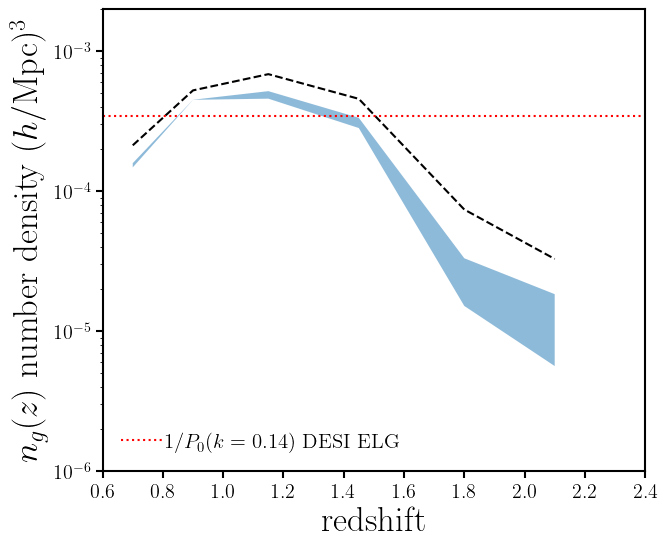

In [29]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)

#sub.plot([], [], c='k', ls='--', label='scaled to 15min')

# based on LAM)
sub.plot(zmid, ngs_ref[:], color='k', ls='--')

sub.fill_between(zmid, ngs0[:], ngs1[:], color='C0', edgecolor='none', alpha=0.5)
# reference n(z)
sub.axhline(1./(2.9e3), c='r', ls=':', label=r'$1/P_0(k=0.14)$ DESI ELG')


sub.legend(loc='lower left', fontsize=15, handletextpad=0.1)
sub.set_xlabel('redshift', fontsize=25)
sub.set_xlim(0.6, 2.4)
sub.set_ylabel(r'$n_g(z)$ number density $(h/{\rm Mpc})^3$', fontsize=25)
sub.set_yscale('log')
sub.set_ylim(1e-6, 2e-3)


In [30]:
for zmin, zmax in zip([0.6, 0.9, 1.2, 1.6], [0.9, 1.2, 1.6, 2.4]): 
    print('%.2f < z < %.2f: %.2e - %.2e, %.2e' % (zmin, zmax, nz_forecast(zmin, zmax, exp15min=True, scale_method='mid'), nz_forecast(zmin, zmax, exp15min=True, scale_method='cut'), 
                                                 0.5 * (nz_forecast(zmin, zmax, exp15min=True, scale_method='mid') + nz_forecast(zmin, zmax, exp15min=True, scale_method='cut'))))

0.60 < z < 0.90: 2.79e-04 - 2.73e-04, 2.76e-04
0.90 < z < 1.20: 3.84e-04 - 4.55e-04, 4.20e-04
1.20 < z < 1.60: 3.45e-04 - 3.89e-04, 3.67e-04
1.60 < z < 2.40: 9.50e-06 - 2.18e-05, 1.56e-05
